In [1]:
import pandas as pd
import numpy as np

# Set random seed so you get the same numbers every time you run it
np.random.seed(42)

# 1. Define the network of warehouses and stores
routes = [
    {'source': 'Hub_A', 'destination': 'Warehouse_B'},
    {'source': 'Hub_A', 'destination': 'Warehouse_C'},
    {'source': 'Warehouse_B', 'destination': 'Store_D'},
    {'source': 'Warehouse_B', 'destination': 'Store_E'},
    {'source': 'Warehouse_C', 'destination': 'Store_F'},
    {'source': 'Warehouse_C', 'destination': 'Store_D'},
    {'source': 'Hub_A', 'destination': 'Store_F'} # A long-haul direct route
]

df = pd.DataFrame(routes)

# 2. Simulate transit times (between 4 and 18 hours)
df['transit_hours'] = np.random.uniform(4.0, 18.0, size=len(df)).round(1)

# 3. Simulate refrigerated truck temperatures in Celsius
# A perfect truck is 4.0°C, but we use a normal distribution to simulate cooling failures
df['avg_temp_celsius'] = np.random.normal(loc=4.0, scale=3.0, size=len(df)).round(2)

# 4. Save the dataset to your data folder
file_path = '../data/supply_chain_routes.csv'
df.to_csv(file_path, index=False)

print(f"Data successfully saved to {file_path}\n")
print(df)

Data successfully saved to ../data/supply_chain_routes.csv

        source  destination  transit_hours  avg_temp_celsius
0        Hub_A  Warehouse_B            9.2              4.84
1        Hub_A  Warehouse_C           17.3              7.03
2  Warehouse_B      Store_D           14.2              2.26
3  Warehouse_B      Store_E           12.4              2.42
4  Warehouse_C      Store_F            6.2              2.29
5  Warehouse_C      Store_D            6.2              1.23
6        Hub_A      Store_F            4.8             -3.84


--- Standard Logistics Route ---
Path: Hub_A -> Store_F
Total Time: 4.8 hours
Total Shelf-Life Lost: 1.01 units

--- Kinetic Cold Chain Route ---
Path: Hub_A -> Store_F
Total Time: 4.8 hours
Total Shelf-Life Lost: 1.01 units



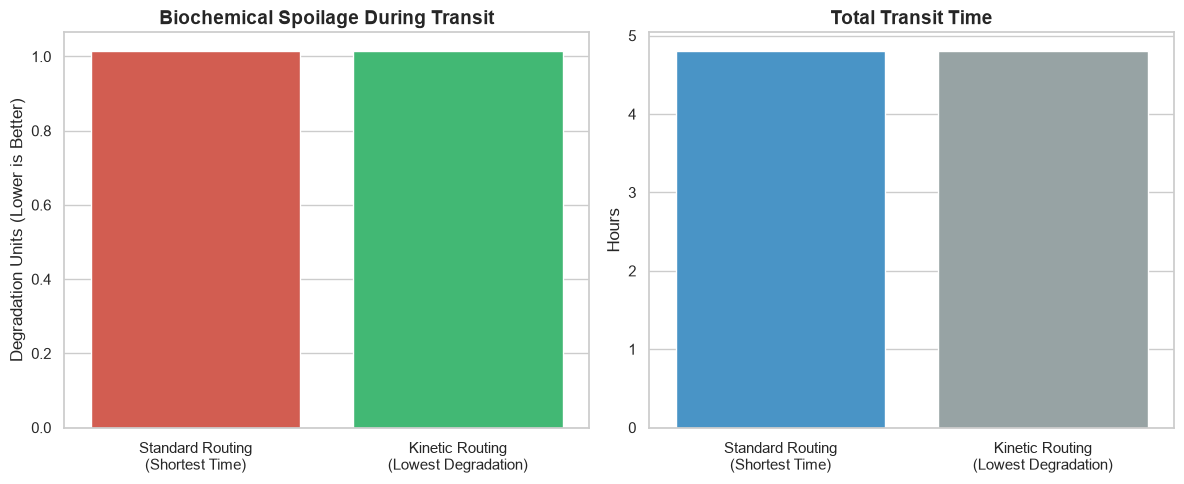

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Tell Jupyter to look in the parent directory for the 'src' folder
sys.path.append(os.path.abspath('../'))

from src.dijkstra_router import build_graph_from_csv, dijkstra_cold_chain, dijkstra_shortest_time
from src.kinetic_models import calculate_degradation

# 1. Load the supply chain graph
file_path = '../data/supply_chain_routes.csv'
graph = build_graph_from_csv(file_path)

# 2. Define our start and end points
start = 'Hub_A'
target = 'Store_F'

# 3. Run Both Algorithms
# Algorithm A: Standard Logistics (Fastest Time)
fastest_path, min_time = dijkstra_shortest_time(graph, start, target)

# Algorithm B: Kinetic Routing (Lowest Degradation)
kinetic_path, min_degradation = dijkstra_cold_chain(graph, start, target)

# 4. Helper function to calculate the degradation of the "Fastest Time" route for a fair comparison
def get_path_degradation(graph, path):
    total_deg = 0
    for i in range(len(path)-1):
        u, v = path[i], path[i+1]
        for neighbor, hrs, temp in graph[u]:
            if neighbor == v:
                total_deg += calculate_degradation(hrs, temp)
                break
    return total_deg

fastest_path_degradation = get_path_degradation(graph, fastest_path)

# 5. Helper function to calculate the time of the "Kinetic" route
def get_path_time(graph, path):
    total_time = 0
    for i in range(len(path)-1):
        u, v = path[i], path[i+1]
        for neighbor, hrs, temp in graph[u]:
            if neighbor == v:
                total_time += hrs
                break
    return total_time

kinetic_path_time = get_path_time(graph, kinetic_path)

# Print the text comparison
print("--- Standard Logistics Route ---")
print(f"Path: {' -> '.join(fastest_path)}")
print(f"Total Time: {min_time} hours")
print(f"Total Shelf-Life Lost: {fastest_path_degradation:.2f} units\n")

print("--- Kinetic Cold Chain Route ---")
print(f"Path: {' -> '.join(kinetic_path)}")
print(f"Total Time: {kinetic_path_time:.1f} hours")
print(f"Total Shelf-Life Lost: {min_degradation:.2f} units\n")

# 6. Plotting the results with Seaborn and Matplotlib
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Spoilage Comparison
sns.barplot(
    x=['Standard Routing\n(Shortest Time)', 'Kinetic Routing\n(Lowest Degradation)'], 
    y=[fastest_path_degradation, min_degradation], 
    palette=['#e74c3c', '#2ecc71'], 
    ax=axes[0],
    hue=['Standard Routing\n(Shortest Time)', 'Kinetic Routing\n(Lowest Degradation)'],
    legend=False
)
axes[0].set_title('Biochemical Spoilage During Transit', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Degradation Units (Lower is Better)')

# Chart 2: Time Comparison
sns.barplot(
    x=['Standard Routing\n(Shortest Time)', 'Kinetic Routing\n(Lowest Degradation)'], 
    y=[min_time, kinetic_path_time], 
    palette=['#3498db', '#95a5a6'], 
    ax=axes[1],
    hue=['Standard Routing\n(Shortest Time)', 'Kinetic Routing\n(Lowest Degradation)'],
    legend=False
)
axes[1].set_title('Total Transit Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Hours')

plt.tight_layout()
plt.show()

In [1]:
import sys
import subprocess

print("1. Installing pip...")
subprocess.run([sys.executable, "-m", "ensurepip", "--upgrade"])

print("2. Installing Streamlit...")
subprocess.run([sys.executable, "-m", "pip", "install", "streamlit"])

print("3. Success! Streamlit is ready.")

1. Installing pip...
2. Installing Streamlit...
3. Success! Streamlit is ready.
